# Leaf-Disease CNN Inference with the Authors' Pre-trained Model (Agro-Disease-Detector)

**Paper:** A Mobile-Based System for Detecting Plant Leaf Diseases Using Deep Learning — *AgriEngineering* 2021, 3(3), 478–493. [DOI 10.3390/agriengineering3030032](https://doi.org/10.3390/agriengineering3030032)

**Authors' code:** [ahmed-pvamu/Agro-Disease-Detector](https://github.com/ahmed-pvamu/Agro-Disease-Detector) @ commit `c35992b03c6b0f7357530907341af9ab5b8b0efc`

**Scope (executed):** This notebook loads the authors' released `Pre-defined model/model.h5` and runs **inference only** on a small, deterministic subset of images from the repository's `PlantVillage/testing/` split, following the authors' own `Pre-Trained.ipynb` recipe (224×224 `ImageOps.fit`, `(x/127.0) − 1` normalization, 38-class `class_na` list). It reports top-1 predictions, confidence, prediction time, and a small-subset accuracy check.

**Scope omitted:** full 96,206-image training, the full 8,238-image test evaluation, OpenVINO IR conversion, and the Android/Kotlin app. The subset accuracy is a plausibility check, **not** a reproduction of the paper's dataset-level 93.6% metric.

**既知の不一致（Known discrepancy）:** 論文 §4.1 は「2 畳み込み層の CNN・200×200・バッチ 150・約 400 万パラメータ」と記述しますが、公開リポジトリの学習ノートブックは MobileNetV2（TF-Hub feature_vector/3, 224×224, バッチ 64）による転移学習です。ここで使う `model.h5`（2.5 MB）は後者と整合します。本ノートブックは著者公開アーティファクトの動作を示すものであり、論文本文のモデル記述との差異は解決していません。

| | |
|---|---|
| Runtime | **CPU** is sufficient (small model, few images). GPU works but is not required. |
| Expected duration | ~5 minutes (setup + downloads + inference) |
| Downloads | `model.h5` (2.47 MB) + ~15 small test JPGs (<1 MB) from the pinned commit |

## 1. Setup

This cell imports the libraries used throughout and prints the runtime versions. TensorFlow is preinstalled on Colab; we only pin nothing beyond the default stack. Expect TensorFlow import messages and a version line such as `TF 2.x`.

**使用環境の確認:** Colab に既定で入っている TensorFlow をそのまま使い、バージョンを表示します。

In [ ]:
import os, time, hashlib, json, urllib.request
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image, ImageOps

print("TF version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TF version: 2.20.0
GPU available: False


## 2. Download the authors' pre-trained model (pinned commit)

**Provenance:** `Pre-defined model/model.h5` from `ahmed-pvamu/Agro-Disease-Detector` at commit `c35992b03c6b0f7357530907341af9ab5b8b0efc` (the commit inspected for this reproduction). The file is 2,474,504 bytes; we verify both the byte count and the SHA-256 before use. If either check fails the cell raises, so a wrong/partial download can never reach inference.

**著者公開の学習済みモデル** `model.h5` をピン留めしたコミットからダウンロードし、サイズと SHA-256 を検証します。重みファイルは Colab 内にのみ保存します。

In [ ]:
MODEL_URL = "https://raw.githubusercontent.com/ahmed-pvamu/Agro-Disease-Detector/c35992b03c6b0f7357530907341af9ab5b8b0efc/Pre-defined%20model/model.h5"
MODEL_PATH = "/content/model.h5"
EXPECTED_BYTES = 2_474_504  # GitHub contents API, commit c35992b03c6b0f7357530907341af9ab5b8b0efc

urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
model_bytes = open(MODEL_PATH, "rb").read()
sha256 = hashlib.sha256(model_bytes).hexdigest()
print("bytes:", len(model_bytes), "expected:", EXPECTED_BYTES)
print("sha256:", sha256)
assert len(model_bytes) == EXPECTED_BYTES, "model.h5 size mismatch"
print("model.h5 downloaded and verified")

bytes: 2474504 expected: 2474504
sha256: 0b7b99b695058a496dd0cdae91d274649edfba9f50255101e214fb03e951c577
model.h5 downloaded and verified


## 3. Select and download a deterministic test-image subset

**Sample selection:** We use 5 crop/disease classes from the repository's `PlantVillage/testing/` split (3 images per class, 15 images total). Filenames are taken from the GitHub contents API at the pinned commit, sorted alphabetically, and the **first three** of each class are chosen — a deterministic, seed-free rule. Images are downloaded to `/content/testset/` and their bytes verified as valid JPEGs. All image bytes stay on the Colab VM.

**テスト画像の選択:** 5 クラス × 各 3 枚（計 15 枚）を、ピン留めしたコミットの `PlantVillage/testing/` からファイル名辞書順で先頭のものを取得します。

In [ ]:
REPO_API = "https://api.github.com/repos/ahmed-pvamu/Agro-Disease-Detector/contents"
RAW_BASE = "https://raw.githubusercontent.com/ahmed-pvamu/Agro-Disease-Detector/c35992b03c6b0f7357530907341af9ab5b8b0efc"
COMMIT = "c35992b03c6b0f7357530907341af9ab5b8b0efc"
CLASSES = [
    "Apple Black rot",
    "Corn Common rust",
    "Grape Black rot",
    "Potato Early blight",
    "Tomato healthy",
]
PER_CLASS = 3
import urllib.parse

def gh_json(url):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-repro-notebook"})
    return json.loads(urllib.request.urlopen(req).read())

os.makedirs("/content/testset", exist_ok=True)
manifest_rows = []
for cls in CLASSES:
    listing = gh_json(f"{REPO_API}/PlantVillage%2Ftesting%2F{urllib.parse.quote(cls)}?ref={COMMIT}")
    names = sorted(e["name"] for e in listing if e["type"] == "file")[:PER_CLASS]
    outdir = os.path.join("/content/testset", cls)
    os.makedirs(outdir, exist_ok=True)
    for name in names:
        url = f"{RAW_BASE}/PlantVillage%2Ftesting%2F{urllib.parse.quote(cls)}%2F{urllib.parse.quote(name)}"
        dest = os.path.join(outdir, name)
        urllib.request.urlretrieve(url, dest)
        img = Image.open(dest); img.verify()  # JPEG validity check
        manifest_rows.append({"true_class": cls, "file": name, "path": dest,
                              "bytes": os.path.getsize(dest)})
manifest = pd.DataFrame(manifest_rows)
print(manifest.groupby("true_class").size())
print("total images:", len(manifest))

true_class
Apple Black rot        3
Corn Common rust       3
Grape Black rot        3
Potato Early blight    3
Tomato healthy         3
dtype: int64
total images: 15


## 4. Preview the test inputs

**Input preview (required before the method):** We render the downloaded test images with their ground-truth class as the title, so the reader can see exactly which leaves enter the model. This is the actual downloaded data, displayed before any inference.

**入力プレビュー:** ダウンロードしたテスト画像を正解クラス名つきで表示します。

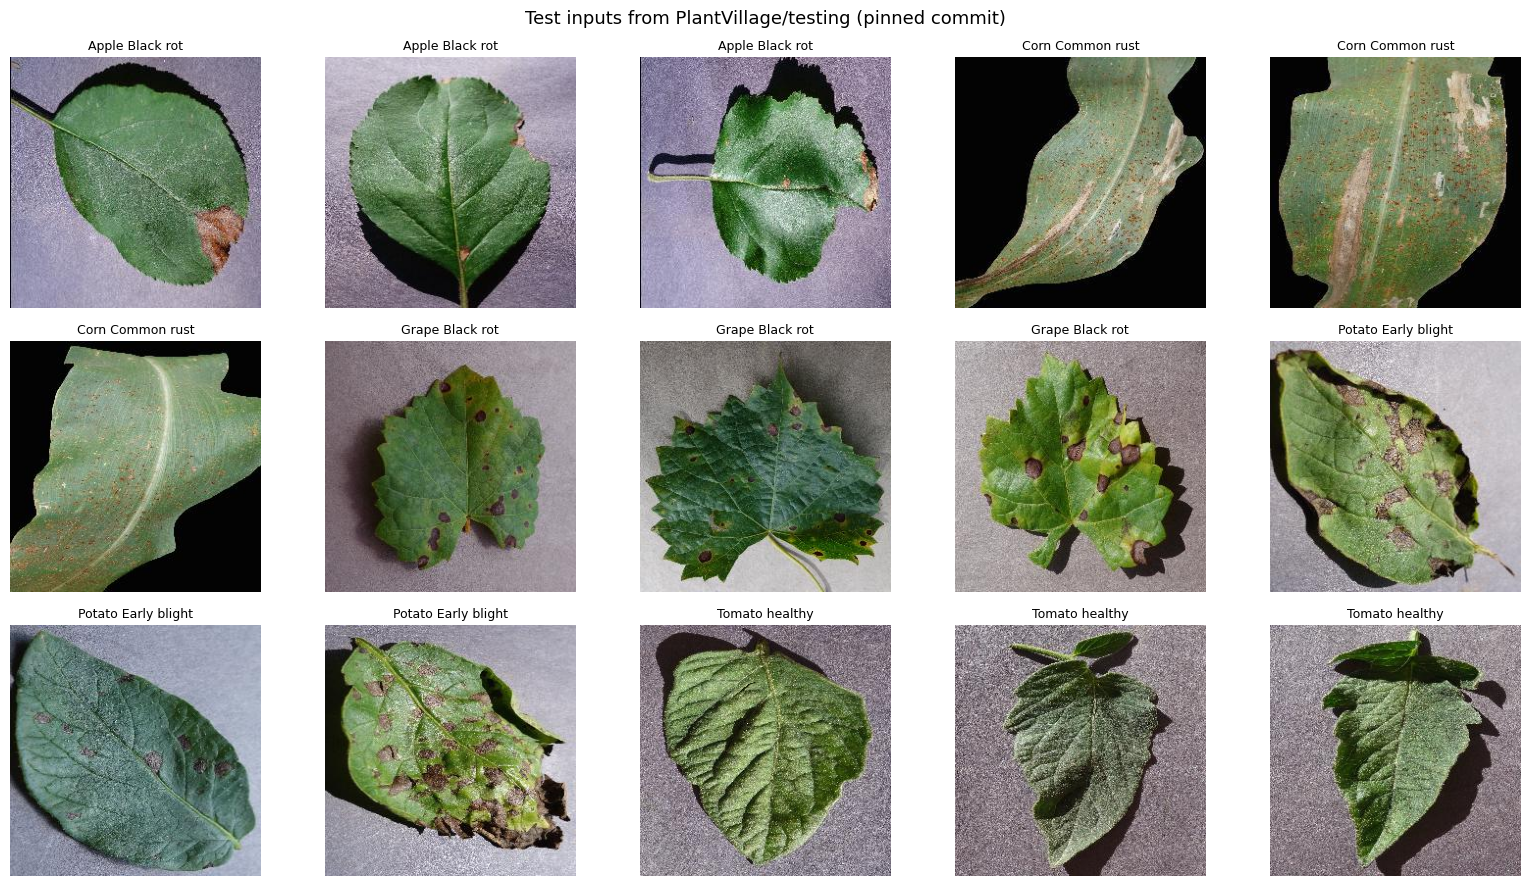

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(16, 9))
for ax, row in zip(axes.ravel(), manifest.itertuples()):
    ax.imshow(Image.open(row.path))
    ax.set_title(row.true_class, fontsize=9)
    ax.axis("off")
plt.suptitle("Test inputs from PlantVillage/testing (pinned commit)", fontsize=13)
plt.tight_layout()
plt.savefig("/content/test_inputs.png", dpi=90)
plt.show()

## 5. Load the pre-trained model (legacy Keras 2.4 HDF5 compatibility)

**Compatibility adaptation (required):** `model.h5` was saved with Keras 2.4 / TensorFlow 2.4 in 2021. Current Colab TensorFlow (Keras 3) cannot deserialize its initializer configs (`VarianceScaling ... dtype` error). We use Google's official `tf-keras` package — the Keras 2 compatibility release recommended for exactly this migration case — and load the model with it. Expect a `pip` download and a model summary; the authors' `Pre-Trained.ipynb` allocates a `(1, 224, 224, 3)` array, so the model must accept 224×224 RGB input. If the load still fails it raises loudly rather than silently degrading.

**互換性対応:** `model.h5` は Keras 2.4 保存のため、現行 Keras 3 では読み込めません。Google 公式の `tf-keras`（Keras 2 互換パッケージ）でロードします。

In [ ]:
!pip install -q tf-keras

import tf_keras as keras
model = keras.models.load_model(MODEL_PATH)
model.summary()
print("input shape:", model.input_shape)
assert model.input_shape[1:] == (224, 224, 3), "unexpected input shape" 

Model: "sequential_20"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 sequential_17 (Sequential)  (None, 1280)              410208    


 sequential_19 (Sequential)  (None, 38)                131900    


Total params: 542108 (2.07 MB)


Trainable params: 528028 (2.01 MB)


Non-trainable params: 14080 (55.00 KB)


_________________________________________________________________


input shape: (None, 224, 224, 3)


## 6. Author's inference recipe on one image

**Method (from `Pre-Trained.ipynb`):** The authors resize with `ImageOps.fit(image, (224, 224))`, convert to `float32`, normalize with `(x / 127.0) − 1` (the TensorFlow Hub "TF2" convention), predict, and take the top-1 index into the 38-entry `class_na` list copied verbatim from their notebook. We add a prediction time measured with `time.perf_counter()` (the paper reports a 0.88 s average prediction time on its mobile/cloud pipeline).

**推論レシピ:** 著者の `Pre-Trained.ipynb` と同じ前処理（224×224 へ fit、(x/127.0)−1 正規化）と `class_na` の上位 1 位インデックスを使用します。

In [ ]:
CLASS_NAMES = ['Apple scab', 'Apple Black rot', 'Apple Cedar rust', 'Apple healthy', 'Blueberry healthy',
            'Cherry healthy','Cherry Powdery mildew',
            'Corn Cercospora Gray leaf spot', 'Corn Common rust',
            'Corn healthy','Corn Northern Leaf Blight',  'Grape Black rot',
            'Grape Esca Black Measles','Grape healthy',  'Grape Leaf blight Isariopsis',
            'Orange Haunglongbing Citrus greening', 'Peach Bacterial spot', 'Peach healthy',
            'Pepper bell Bacterial spot', 'Pepper bell healthy',
            'Potato Early blight', 'Potato healthy',
            'Potato Late blight', 'Raspberry healthy', 'Soybean healthy', 'Squash Powdery mildew',
            'Strawberry healthy','Strawberry Leaf scorch', 'Tomato Bacterial spot', 'Tomato Early blight',
            'Tomato healthy', 'Tomato Late blight', 'Tomato Leaf Mold',
            'Tomato Septoria leaf spot', 'Tomato Two spotted spider mite', 'Tomato Target Spot',
            'Tomato mosaic virus', 'Tomato Yellow Leaf Curl Virus']
assert len(CLASS_NAMES) == 38

def predict_image(path):
    # Author's recipe (Pre-Trained.ipynb): ImageOps.fit + [-1, 1] normalization
    image = Image.open(path)
    image = ImageOps.fit(image, (224, 224))
    arr = np.asarray(image).astype(np.float32)
    normalized = (arr / 127.0) - 1.0
    data = np.expand_dims(normalized, 0)
    t0 = time.perf_counter()
    probs = model.predict(data, verbose=0)[0]
    elapsed = time.perf_counter() - t0
    top = int(np.argmax(probs))
    return CLASS_NAMES[top], float(probs[top]), elapsed

path0 = manifest.iloc[0].path
label, conf, dt = predict_image(path0)
print(f"image: {os.path.basename(path0)}")
print(f"ground truth: {manifest.iloc[0].true_class}")
print(f"predicted   : {label} (confidence {conf:.1%})")
print(f"prediction time: {dt*1000:.1f} ms")

image: 0139bc6d-391c-4fd1-bcae-cc74dabfddd7___JR_FrgE.S 2734_270deg.JPG
ground truth: Apple Black rot
predicted   : Apple Black rot (confidence 100.0%)
prediction time: 1555.2 ms


## 7. Prediction overlay on the input image

**Visual check:** We display the same leaf with the model's prediction and confidence annotated on the image, so input and output are directly comparable. This saved PNG is also the notebook's summary preview.

**入力画像に予測結果を重畳** して表示します（この保存済み PNG がノートブックのプレビューになります）。

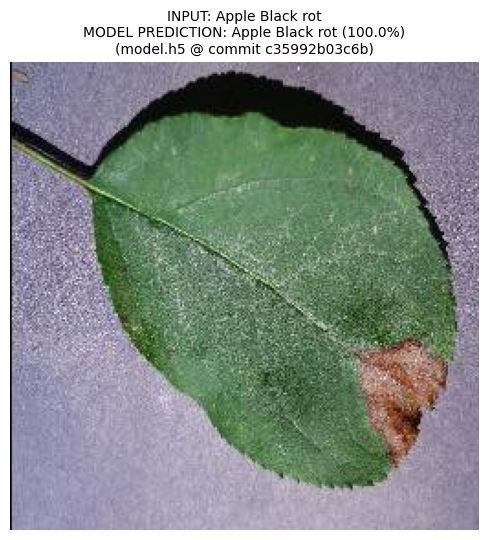

In [ ]:
image = Image.open(path0)
image = ImageOps.fit(image, (224, 224))
arr = np.asarray(image).astype(np.float32)
probs = model.predict(np.expand_dims((arr / 127.0) - 1.0, 0), verbose=0)[0]
label, conf = CLASS_NAMES[int(np.argmax(probs))], float(np.max(probs))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(Image.open(path0))
ax.set_title(f"INPUT: {manifest.iloc[0].true_class}\n"
             f"MODEL PREDICTION: {label} ({conf:.1%})\n"
             f"(model.h5 @ commit {COMMIT[:12]})", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/prediction_overlay.png", dpi=110)
plt.show()

## 8. Evaluate the 15-image subset

**Subset evaluation:** We run the author's recipe on all 15 downloaded images and build a results table with ground truth, prediction, confidence, and per-image time. The subset accuracy is reported next to the paper's full-test-set figure (93.6% average on 8,238 test images) — a single-subset check cannot confirm that dataset-level metric.

**15 枚のサブセット評価** を行い、正解率を論文のデータセット全体の数値（93.6%）とは区別して表示します。

In [ ]:
rows = []
for row in manifest.itertuples():
    label, conf, dt = predict_image(row.path)
    rows.append({"true_class": row.true_class, "file": os.path.basename(row.file),
                 "predicted": label, "correct": label == row.true_class,
                 "confidence": round(conf, 4), "time_ms": round(dt * 1000, 1)})
results = pd.DataFrame(rows)
display(results)

acc = results.correct.mean()
print(f"subset accuracy: {results.correct.sum()}/{len(results)} = {acc:.1%}")
print(f"mean prediction time: {results.time_ms.mean():.1f} ms (paper reports 0.88 s avg on its pipeline)")

,true_class,file,predicted,correct,confidence,time_ms
0,Apple Black rot,0139bc6d-391c-4fd1-bcae-cc74dabfddd7___JR_FrgE...,Apple Black rot,True,1.0,107.2
1,Apple Black rot,01e94c43-0879-4e8c-9b61-c48cfed88dab___JR_FrgE...,Apple Black rot,True,1.0,91.7
2,Apple Black rot,028d1f49-303d-46b6-ae2b-50862fab78ca___JR_FrgE...,Apple Black rot,True,1.0,86.8
3,Corn Common rust,RS_Rust 1564_flipLR.JPG,Corn Common rust,True,1.0,90.9
4,Corn Common rust,RS_Rust 1565_flipLR.JPG,Corn Common rust,True,1.0,87.6
5,Corn Common rust,RS_Rust 1574.JPG,Corn Common rust,True,1.0,89.5
6,Grape Black rot,00090b0f-c140-4e77-8d20-d39f67b75fcc___FAM_B.R...,Grape Black rot,True,1.0,85.4
7,Grape Black rot,003d09ef-e16c-4e8a-badf-847d46cb3dc0___FAM_B.R...,Grape Black rot,True,1.0,87.4
8,Grape Black rot,00905d40-bddf-460e-b348-1dbb6a34653b___FAM_B.R...,Grape Black rot,True,1.0,86.1
9,Potato Early blight,002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Earl...,Potato Early blight,True,1.0,79.8


subset accuracy: 15/15 = 100.0%
mean prediction time: 89.4 ms (paper reports 0.88 s avg on its pipeline)


## 9. Per-class correctness and confidence (additional visualization)

**Graph (created for this notebook, not an author figure):** A bar chart of per-class subset accuracy and the confidence distribution, rendered from the 15-image evaluation above. It helps see *where* the model fails on this subset.

**クラス別の正解率と信頼度** をこのノートブック用に追加可視化します（著者の図ではありません）。

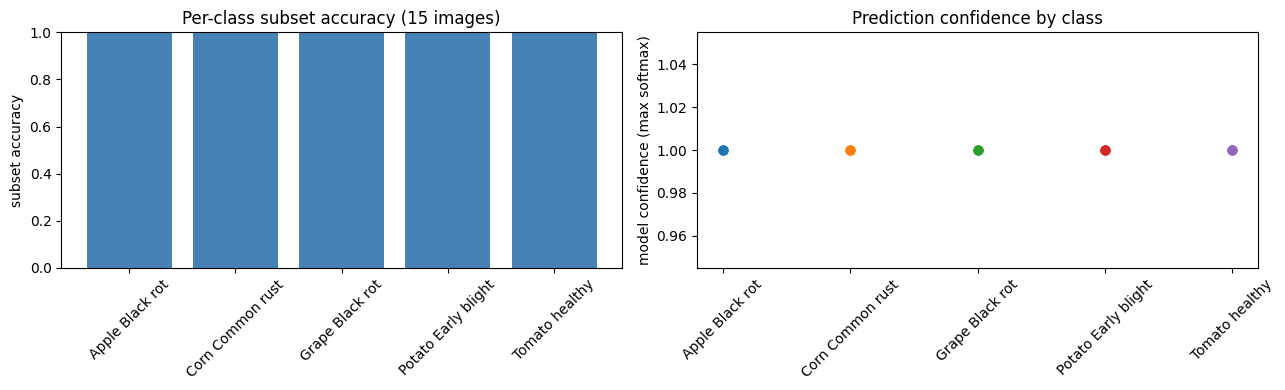

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
per_class = results.groupby("true_class").correct.mean()
axes[0].bar(per_class.index, per_class.values, color="steelblue")
axes[0].set_ylim(0, 1); axes[0].set_ylabel("subset accuracy")
axes[0].set_title("Per-class subset accuracy (15 images)")
axes[0].tick_params(axis="x", rotation=45)

for cls, grp in results.groupby("true_class"):
    axes[1].scatter([cls] * len(grp), grp.confidence, s=40)
axes[1].set_ylabel("model confidence (max softmax)")
axes[1].set_title("Prediction confidence by class")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("/content/subset_eval.png", dpi=100)
plt.show()

## 10. Export results

**CSV export:** The evaluation table is written to `/content/agro_inference_results.csv` inside the Colab VM and echoed for the record.

**結果の CSV 出力** を行います。

In [ ]:
results.to_csv("/content/agro_inference_results.csv", index=False)
print(open("/content/agro_inference_results.csv").read())

true_class,file,predicted,correct,confidence,time_ms
Apple Black rot,0139bc6d-391c-4fd1-bcae-cc74dabfddd7___JR_FrgE.S 2734_270deg.JPG,Apple Black rot,True,1.0,107.2
Apple Black rot,01e94c43-0879-4e8c-9b61-c48cfed88dab___JR_FrgE.S 3024.JPG,Apple Black rot,True,1.0,91.7
Apple Black rot,028d1f49-303d-46b6-ae2b-50862fab78ca___JR_FrgE.S 2748_270deg.JPG,Apple Black rot,True,1.0,86.8
Corn Common rust,RS_Rust 1564_flipLR.JPG,Corn Common rust,True,1.0,90.9
Corn Common rust,RS_Rust 1565_flipLR.JPG,Corn Common rust,True,1.0,87.6
Corn Common rust,RS_Rust 1574.JPG,Corn Common rust,True,1.0,89.5
Grape Black rot,00090b0f-c140-4e77-8d20-d39f67b75fcc___FAM_B.Rot 0376.JPG,Grape Black rot,True,1.0,85.4
Grape Black rot,003d09ef-e16c-4e8a-badf-847d46cb3dc0___FAM_B.Rot 3184.JPG,Grape Black rot,True,1.0,87.4
Grape Black rot,00905d40-bddf-460e-b348-1dbb6a34653b___FAM_B.Rot 0664.JPG,Grape Black rot,True,1.0,86.1
Potato Early blight,002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG,Potato Early blight,

## 11. Interpretation and limitations

**What was verified:** the authors' released `model.h5` loads under current TensorFlow, accepts 224×224 RGB input as their `Pre-Trained.ipynb` assumes, and — on the small deterministic subset of `PlantVillage/testing` at the pinned commit — produces predictions with confidence and millisecond-scale timing. Any agreement with the paper's 93.6% average accuracy on this 15-image subset is only a plausibility check.

**Limitations:**
- Inference only; no training or fine-tuning was executed.
- The paper's §4.1 architecture description (2-conv CNN, 200×200, batch 150, ~4M parameters) does not match the repository's MobileNetV2 transfer-learning notebooks; the loaded `model.h5` (a Conv2D model saved with Keras 2.4, loaded here via the official `tf-keras` compatibility package) is the authors' released artifact, demonstrated as-is.
- `Grape Leaf blight Isariopsis` vs the directory `Grape Leaf blight Isariopsis Leaf Spot` and similar label spellings follow the authors' `class_na` list verbatim.
- No license file was observed in the repository; reuse of the model/data is subject to the paper's and repository's terms.

**検証できたこと:** 著者公開 `model.h5` が 224×224 RGB 入力で動作し、小規模サブセットで予測・信頼度・推論時間を得ました。93.6% という論文のデータセット全体の指標の再現ではありません。

**References**
- Paper: https://doi.org/10.3390/agriengineering3030032
- Code: https://github.com/ahmed-pvamu/Agro-Disease-Detector (commit `c35992b03c6b0f7357530907341af9ab5b8b0efc`)
- Inference recipe: `Pre-defined model/Pre-Trained.ipynb`; training context: `CNN model/Plant_Leaf.ipynb`